## Moving Beyond Linearity 

In [1]:
%matplotlib inline
%autosave 60
import csv
import math
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import statsmodels.api as sm
import sklearn.metrics as sklm
from patsy import dmatrix
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, StandardScaler
from sklearn.model_selection import KFold
from mlxtend.evaluate import bias_variance_decomp
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV, LinearRegression, ElasticNet
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.preprocessing import scale
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.isotonic import IsotonicRegression
# from sklearn.kernel_ridge import KernelRidge
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.datasets import load_boston

RANDOM_STATE = 42

Autosaving every 60 seconds


## Bias and Variance decomposition

Consider a general regression setup, where we are given a random pair $(X, y)$. We would like to "predict" $y$ with some function of $X$, say, $f(X)$. Suppose that we obtain some $\hat{f}$, how well does it estimate $f$? We define the **expected prediction error** of predicting $y$ using $\hat{f}(X)$. A good $\hat{f}$ will have a low expected prediction error.  The expected prediction error of predicting $y$ using $\hat{f}(X)$ when $X = x$ has been decomposed into two types of errors:

  - **Reducible error**: This is the expected squared error loss of estimation $f(x)$ using $\hat{f}(x)$ at a fixed point $x$. 
  - **Irreducible error**: This is simply the variance of $y$ given that $X = x$, essentially noise that we do not want to learn. This is also called the **Bayes error**.
    
After decomposing the expected prediction error into reducible and irreducible error, we can further decompose the reducible error into bias squared and variance, which is given by the following equation:

$$
\text{MSE}\left(f(x), \hat{f}(x)\right) = \text{bias}^2 \left(\hat{f}(x) \right) + \text{var} \left(\hat{f}(x) \right)
$$

From the above term, it turns out that there is a **bias-variance tradeoff**. If there is more bias in our estimation, then that would have lesser variance and vice versa. In other words, complex models tend to be unbiased, but highly variable and simple models are often extremely biased but have low variance. Often, the term bias-variance tradeoff is used to describe the performance of a model. In general, we might say that "high variance" is proportional to overfitting, and "high bias" is proportional to underfitting. Therefore, we need to select a model that appropriately balances the tradeoff between bias and variance, and thus minimizes the reducible error.

Let's do some experimentation to look at bias-variance tradeoff and to start with importing the datasets.

## Importing Datasets

We are going to use Boston dataset provided by the `sklearn.datasets` package. There are more interesting datasets in the package if you want to explore them during your free time!

Run the following cell to load the data. `load_boston()` will return a dictionary object which includes keys for:
- `data` : the covariates (X)
- `target` : the response vector (Y)
- `feature_names`: the column names
- `DESCR` : a full description of the data
- `filename`: name of the csv file

In [2]:
boston_data = load_boston()

C:\Users\ssehra\AppData\Local\Continuum\anaconda3\envs\r_40\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function load_boston is deprecated; `load_boston` is deprecated in 1.0 and will be removed in 1.2.

    The Boston housing prices dataset has an ethical problem. You can refer to
    the documentation of this function for further details.

    The scikit-learn maintainers therefore strongly discourage the use of this
    dataset unless the purpose of the code is to study and educate about
    ethical issues in data science and machine learning.

    In this special case, you can fetch the dataset from the original
    source::

        import pandas as pd
        import numpy as np


        data_url = "http://lib.stat.cmu.edu/datasets/boston"
        raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
        data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
        target = raw_df.values[1::2, 2]

    Alternative datasets inclu

Let's now convert this data into a pandas DataFrame. 

In [3]:
boston = pd.DataFrame(boston_data['data'], columns=boston_data['feature_names'])
boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


Now, name the target variable `MEDV` as `response_variable`.

In [4]:
y = pd.Series(boston_data['target'])

Let's prepare the data!!

In [5]:
scaler = MinMaxScaler()
boston[["ZN", "AGE", "TAX", "PTRATIO", "B"]] = scaler.fit_transform(boston[["ZN", "AGE", "TAX", "PTRATIO","B"]])
boston["CHAS"] = boston["CHAS"].astype("int").astype("category")
boston=pd.get_dummies(boston, columns=["CHAS"], drop_first=True)
X = boston

## Multiple Linear Regression Model

Let's fit a linear model to describe the relationship between the housing price (`response_variable`) and all available predictors of the `boston` dataset.

In [6]:
np.random.seed(RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.10)

In [7]:
model_linear = LinearRegression()
model_linear.fit(X_train, y_train);

<div class="alert alert-success">

To report the performance measures of the regression model, fill out the functions below to:

a) Compute i) Mean Square Error ii) Root Mean Square Error iii) Mean Absolute Error iv) Median Absolute Error and v) R-Sqaure values.
    
__Hint:__ The sklearn.metrics (loaded at the top as `sklm`) module implements functions assessing prediction error for specific purposes. Such as:
    
  - .mean_squared_error(y_true, y_predicted)}
    
  - .mean_absolute_error(y_true, y_predicted)}
    
  - .median_absolute_error(y_true, y_predicted)
    
  - .r2_score(y_true, y_predicted)

b) Create a residual plot.

c) Create a histogram of residuals.
    
d) Evaluate the performance of the model `model_linear` fitted above using metrics defined in part a) and create a histogram and residual plots using function defined in part b) and c), respectively.
    

In [8]:
# Part a)
def print_metrics(y_true, y_predicted):
    '''
    Print Mean Square Error; Root Mean Square Error; 
    Mean Absolute Error; Median Absolute Error; and R-Sqaure metrics about the model
    Args:
        y_true  (NumPy array ): Actual data
        y_predicted (NumPy array): Predictions made by model 

    Return:
        None
    '''
    ## Print the usual metrics and the R^2 values
    print(f'Mean Square Error: {sklm.mean_squared_error(y_true, y_predicted)}') # SOLUTION
    print(f'Root Mean Square Error: {np.sqrt(sklm.mean_squared_error(y_true, y_predicted))}') # SEED
    print(f'Mean Absolute Error: {sklm.mean_absolute_error(y_true, y_predicted)}') # SEED
    print(f'Median Absolute Error: {sklm.median_absolute_error(y_true, y_predicted)}') # SEED
    print(f'R-Sqaure: {sklm.r2_score(y_true, y_predicted)}') # SEED

In [9]:
  
# Part b)
def resid_plot(y_true, y_predicted):
    '''
    Create a residual plot of actual data vs predicted data.

    Args:
        y_true  (NumPy array ): Actual data
        y_predicted (NumPy array): Predictions made by model 

    Return:
        None
    '''
    residuals = np.subtract(y_true, y_predicted) # SOLUTION
    smoothed = lowess(residuals,y_predicted)
    top3 = abs(residuals).sort_values(ascending = False)[:3]
    fig, ax = plt.subplots()
    ax.scatter(y_predicted, residuals, edgecolors = 'k', facecolors = 'none')
    ax.plot(smoothed[:,0],smoothed[:,1],color = 'r')
    ax.set_ylabel('Residuals')
    ax.set_xlabel('Fitted Values')
    ax.set_title('Residuals vs. Fitted')
    ax.plot([min(y_predicted),max(y_predicted)],[0,0],color = 'k',linestyle = ':', alpha = .3)
    plt.show()

In [10]:
# Part c)
def hist_resids(y_true, y_predicted): 
    '''
    Create a histogram plot of residuals.

    Args:
        y_true  (NumPy array ): Actual data
        y_predicted (NumPy array): Predictions made by model 

    Return:
        None
    '''
    ## first compute vector of residuals. 
    residuals = np.subtract(y_true, y_predicted) # SOLUTION
    ## now make the residual plots
    sns.distplot(residuals)  # SOLUTION
    plt.title('Histogram of residuals')
    plt.xlabel('Residual value')
    plt.ylabel('count')
    plt.show()

Mean Square Error: 14.995852876582612
Root Mean Square Error: 3.872447917865728
Mean Absolute Error: 2.8342104578589593
Median Absolute Error: 2.1443700003061714
R-Sqaure: 0.759813553353248


C:\Users\ssehra\AppData\Local\Continuum\anaconda3\envs\r_40\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


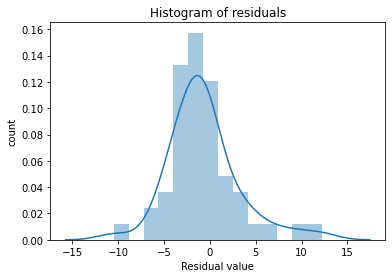

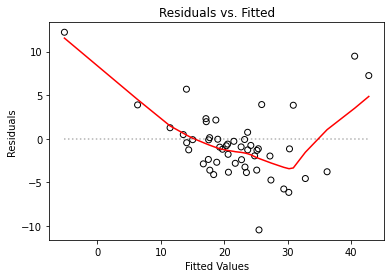

In [11]:
# Part d)
y_predicted = model_linear.predict(X_test) # SOLUTION
print_metrics(y_test, y_predicted)   # SOLUTION
hist_resids(y_test, y_predicted)   # SEED
resid_plot(y_test, y_predicted)  # SEED

## Polynomial Regression

Sometimes we can get even more accuracy by adding more features. For example, the code below adds the square term, and cube term of every numerical feature to the design matrix.

In [12]:
boston_poly = boston.copy()
cols=boston.loc[:, ~boston.columns.isin(['CHAS_1'])].columns # Selecting numeric columns names
for feature_name in cols:
    boston_poly[feature_name + "^2"] = boston_poly[feature_name] ** 2
    boston_poly[feature_name + "^3"] = boston_poly[feature_name] ** 3
boston_poly.head(5)

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,...,RAD^2,RAD^3,TAX^2,TAX^3,PTRATIO^2,PTRATIO^3,B^2,B^3,LSTAT^2,LSTAT^3
0,0.00632,0.18,2.31,0.538,6.575,0.641607,4.0900,1.0,0.208015,0.287234,...,1.0,1.0,0.043270,0.009001,0.082503,0.023698,1.000000,1.000000,24.8004,123.505992
1,0.02731,0.00,7.07,0.469,6.421,0.782698,4.9671,2.0,0.104962,0.553191,...,4.0,8.0,0.011017,0.001156,0.306021,0.169288,1.000000,1.000000,83.5396,763.551944
2,0.02729,0.00,7.07,0.469,7.185,0.599382,4.9671,2.0,0.104962,0.553191,...,4.0,8.0,0.011017,0.001156,0.306021,0.169288,0.979580,0.969527,16.2409,65.450827
3,0.03237,0.00,2.18,0.458,6.998,0.441813,6.0622,3.0,0.066794,0.648936,...,9.0,27.0,0.004461,0.000298,0.421118,0.273279,0.988585,0.982926,8.6436,25.412184
4,0.06905,0.00,2.18,0.458,7.147,0.528321,6.0622,3.0,0.066794,0.648936,...,9.0,27.0,0.004461,0.000298,0.421118,0.273279,1.000000,1.000000,28.4089,151.419437


In [13]:
np.random.seed(RANDOM_STATE)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(boston_poly, y, test_size = 0.10) 
model_poly = LinearRegression()
model_poly.fit(X_train_2, y_train_2);

Let's make the model more complex by adding more features. For example, the code below adds the square, cube, quad, square root, and hyperbolic tangent of numeric features to the design matrix. We've chosen these bizarre features specifically to highlight overfitting.

In [14]:
boston_with_extra_features = boston.copy()
cols=boston.loc[:, ~boston.columns.isin(['CHAS'])].columns # Selecting numeric columns names
for feature_name in cols:
    boston_with_extra_features[feature_name + "^2"] = boston_with_extra_features[feature_name] ** 2
    boston_with_extra_features[feature_name + "^3"] = boston_with_extra_features[feature_name] ** 3
    boston_with_extra_features[feature_name + "^4"] = boston_with_extra_features[feature_name] ** 4
    boston_with_extra_features["sqrt" + feature_name] = np.sqrt(boston_with_extra_features[feature_name])
    boston_with_extra_features["tanh" + feature_name] = np.tanh(boston_with_extra_features[feature_name])
boston_with_extra_features.head(5)

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,...,LSTAT^2,LSTAT^3,LSTAT^4,sqrtLSTAT,tanhLSTAT,CHAS_1^2,CHAS_1^3,CHAS_1^4,sqrtCHAS_1,tanhCHAS_1
0,0.00632,0.18,2.31,0.538,6.575,0.641607,4.0900,1.0,0.208015,0.287234,...,24.8004,123.505992,615.059840,2.231591,0.999905,0,0,0,0.0,0.0
1,0.02731,0.00,7.07,0.469,6.421,0.782698,4.9671,2.0,0.104962,0.553191,...,83.5396,763.551944,6978.864768,3.023243,1.000000,0,0,0,0.0,0.0
2,0.02729,0.00,7.07,0.469,7.185,0.599382,4.9671,2.0,0.104962,0.553191,...,16.2409,65.450827,263.766833,2.007486,0.999368,0,0,0,0.0,0.0
3,0.03237,0.00,2.18,0.458,6.998,0.441813,6.0622,3.0,0.066794,0.648936,...,8.6436,25.412184,74.711821,1.714643,0.994426,0,0,0,0.0,0.0
4,0.06905,0.00,2.18,0.458,7.147,0.528321,6.0622,3.0,0.066794,0.648936,...,28.4089,151.419437,807.065599,2.308679,0.999953,0,0,0,0.0,0.0


Now, 

a) Split the boston_with_extra_features dataset into training and test sets. Remember that `MEDV` (median housing prices) is the response vector represented in the `target` attribute. Use the [`train_test_split`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function to split out 10% of the data for the test set. Call the resulting splits `X_train_3`, `X_test_3`, `y_train_3`, `y_test_3`.
    
b) Fit a linear regression model (name it `model_complex`) using `X_train_3` and `y_train_3` datasets as predictors variables and `response_variable`. 
      
c) Compute the metrics for this model (`model_complex`) using the test data set `X_test_3`. Is this model better than obtained in previous fitted models (`model_linear`, 'model_poly'). 
    
d) Do you witness that adding more variable always increase the predictive power of the model? Comment on it.
    
_Hint:_ Compute the predictions for the `model_poly` and `model_complex` and print the metrics to perform the comparison of the models.



In [15]:
np.random.seed(RANDOM_STATE)
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(boston_with_extra_features, y, test_size = 0.10) # SOLUTION
model_complex = LinearRegression() 
model_complex.fit(X_train_3, y_train_3); 

y_predicted_poly = model_poly.predict(X_test_2) 
print_metrics(y_test_2, y_predicted_poly) 
print("#"*60)
y_predicted_complex = model_complex.predict(X_test_3) 
print_metrics(y_test_3, y_predicted_complex) 

# Part d)

# BEGIN SOLUTION

# Based on the results, we see that `model_poly` performed better than `model_complex`. The results 
# shown that adding variables does not always help in increasing the predictive power of the model. It can also increase due
# to increase in the variance.

# END SOLUTION

Mean Square Error: 6.946285092632038
Root Mean Square Error: 2.6355805987736436
Mean Absolute Error: 2.061974106232368
Median Absolute Error: 1.669661965330178
R-Sqaure: 0.8887423377966079
############################################################
Mean Square Error: 10.047980541214283
Root Mean Square Error: 3.1698549716373905
Mean Absolute Error: 2.261792421423917
Median Absolute Error: 1.9054486003326012
R-Sqaure: 0.839062922127044


Let's compute the training, test error loss, bias, variance as we are adding each additional feature for datasets X_train_2, X_test_2, y_train_2, y_test_2 by running the code below:

In [16]:
train_error_vs_N = []
test_error_vs_N = []
loss_vs_N= []
bias_vs_N= [] 
var_vs_N= []
range_of_num_features = range(1, X_train_2.shape[1] + 1)
model_test=LinearRegression()
for N in range_of_num_features:
    # np.random.seed(RANDOM_STATE)
    X_train_first_N_features = X_train_2.iloc[:, :N]    
    model_test.fit(X_train_first_N_features,y_train_2)
    train_error_overfit = np.sqrt(sklm.mean_squared_error(y_train_2, model_test.predict(X_train_first_N_features)))
    train_error_vs_N.append(train_error_overfit)
    
    X_test_first_N_features = X_test_2.iloc[:, :N]
    test_error_overfit = np.sqrt(sklm.mean_squared_error(y_test_2, model_test.predict(X_test_first_N_features)))  
    test_error_vs_N.append(test_error_overfit)
    
    avg_loss, avg_bias, avg_var = bias_variance_decomp(model_test, X_train_first_N_features.values, y_train_2.values, 
                                                X_test_first_N_features.values, y_test_2.values, loss='mse',
                                                num_rounds=200, random_seed=1)
    loss_vs_N.append(avg_loss)
    bias_vs_N.append(avg_bias)
    var_vs_N.append(avg_var)

Now, 

<div class="alert alert-success">

a) Use the lists, `train_error_vs_N` and `test_error_vs_N` from above for creating a line plot of test error, and train error vs the number of predictors. Do you see, even though our training error continues to decrease, our test error starts increasing which means additional features aren't actually useful when applied to unseen data. Comment on the generalizability of the model.

b) Use the lists, `loss_vs_N`, `bias_vs_N`, and `var_vs_N` from the previous code chunk to create a line plot of expected loss, bias, and variance vs the number of features. Do you witness that as we keep adding features, the bias starts decreasing and variance started to increases? Comment on the trend of the expected loss.  
      
<div>

Text(0, 0.5, 'RMSE')

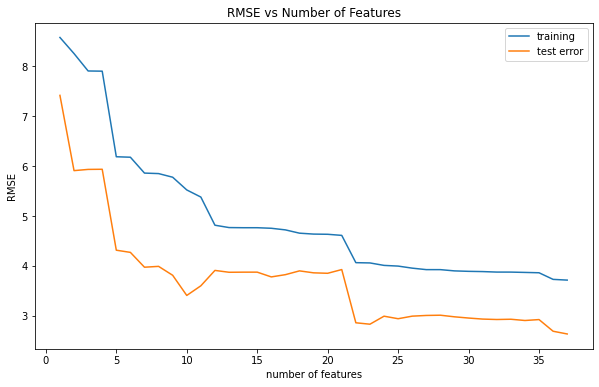

In [17]:
# Part a)
plt.figure(figsize=(10, 6))
plt.plot(range_of_num_features, train_error_vs_N) # SOLUTION
plt.plot(range_of_num_features, test_error_vs_N) # SOLUTION
plt.legend(["training", "test error"])
plt.title('RMSE vs Number of Features')
plt.xlabel("number of features")
plt.ylabel("RMSE")

# BEGIN SOLUTION NO PROMPT
# As we add each additional feature for datasets X_train_2, X_test_2, y_train_2, y_test_2, we see that our model 
# is beginning to overfit. That is, even though our training error continues to decrease, 
# our test error starts increasing which means additional features aren't actually useful when applied to unseen 
# data. That is, our model isn't generalizable.

# END SOLUTION

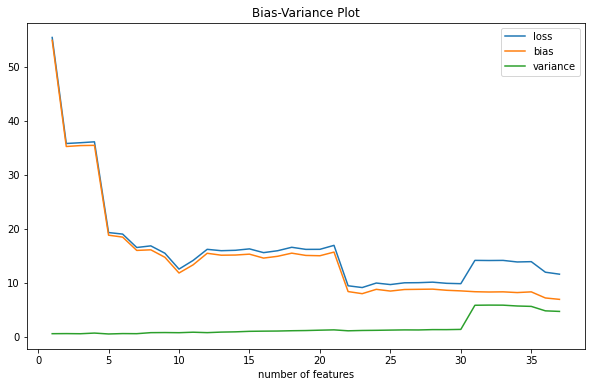

In [18]:
# Part b)
plt.figure(figsize=(10, 6))
plt.plot(range_of_num_features, loss_vs_N) # SOLUTION
plt.plot(range_of_num_features, bias_vs_N) # SOLUTION
plt.plot(range_of_num_features, var_vs_N) # SOLUTION
plt.legend(["loss", "bias", "variance",])
plt.title('Bias-Variance Plot')
plt.xlabel("number of features")
plt.show();
# BEGIN SOLUTION NO PROMPT
# Yes,  as we keep adding features, the bias starts decreasing and variance started to increases.
# The expected loss initially decreased and thereafter started to increase. The lowest value of the expected loss
# suggests us the optimal number of features for our analysis (prediction).
# END SOLUTION

Now, 
<div class="alert alert-success">

a) Compute the bias-variance decomposition of all three models created above (model_linear, model_poly, model_comples) using avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(MODEL_NAME, X_TRAIN.values, Y_TRAIN.values, X_TEST.values, Y_TEST.values, loss="mse", num_rounds=200, random_RANDOM_STATE=1) from mlxtend.evaluate package. 
    
_Note: .values are used to convert the Series into numpy array._
    
d) Do you witness that adding more variable always increase the predictive power of the model? Comment on it.   


In [19]:
np.random.seed(RANDOM_STATE)

avg_expected_loss_linear, avg_bias_linear, avg_var_linear=bias_variance_decomp(model_linear, X_train.values, y_train.values, X_test.values, y_test.values, loss='mse',num_rounds=200, random_seed=RANDOM_STATE) 

avg_expected_loss_poly, avg_bias_poly, avg_var_poly = bias_variance_decomp(model_poly, X_train_2.values, y_train_2.values, X_test_2.values, y_test_2.values, loss='mse',num_rounds=200, random_seed=RANDOM_STATE) 

avg_expected_loss_complex, avg_bias_complex, avg_var_complex = bias_variance_decomp(model_complex, X_train_3.values, y_train_3.values, X_test_3.values, y_test_3.values, loss='mse', num_rounds=200, random_seed=RANDOM_STATE) 

results = [[avg_expected_loss_linear, avg_bias_linear, avg_var_linear], [avg_expected_loss_poly, avg_bias_poly, avg_var_poly], [avg_expected_loss_complex, avg_bias_complex, avg_var_complex]] 

results= pd.DataFrame(results, columns = ['Average Expected Loss', 'Average Bias', 'Average Variance'], index =['Linear Model', 'Polynomial Model', 'Complex Model']) 
 
results

# BEGIN SOLUTION

# The results 
# shown that adding variables does not always help in increasing the predictive power of the model. The bias 
# initally decreased and then increases, also the expected loss increases and variance increase as the complexity of the model 
# increased.

# END SOLUTION

,Average Expected Loss,Average Bias,Average Variance
Linear Model,15.640836,14.795001,0.845835
Polynomial Model,8.222229,6.768606,1.453622
Complex Model,15.450516,10.451720,4.998795


## Polynomial Regression

In [20]:
class PolynomialRegression:
    def __init__(self, X_train, X_test, y_train, y_test, degree):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.degree = degree
        self.model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        self.model.fit(self.X_train, self.y_train)
    
    def predict(self):
        return self.model.predict(self.X_test)
    
    def mse(self, y_pred):
        return mean_squared_error(self.y_test, y_pred)
    
    def find_optimal_degree(self, X, y, degrees):
        """
        Find the optimal degree for the polynomial regression model"""
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        mse_values = []
        for degree in degrees:
            model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            mse_values.append(mse)
        
        optimal_degree = degrees[np.argmin(mse_values)]
        return optimal_degree
        
    def plot_fitted_values(self, alpha=0.05):
        """ Plot the fitted values with the confidence interval"""
        optimal_degree = self.find_optimal_degree(self.X_train, self.y_train, [1,2,3,4,5,6,7,8,9,10])
        model = make_pipeline(PolynomialFeatures(optimal_degree), LinearRegression())
        model.fit(self.X_train, self.y_train)

        # Predict the fitted values on all the data
        X_plot = np.linspace(self.X_train.min(), self.X_train.max(), 100).reshape(-1, 1)
        y_plot = model.predict(X_plot)

        # Calculate the standard deviation of the residuals
        residuals = y_test - model.predict(self.X_test)
        sigma = np.sqrt(np.var(residuals))

        # Calculate the t-value for the given confidence level
        t_value = stats.t.ppf(1 - alpha / 2, df=len(self.X_train) - model.steps[-1][-1].coef_.shape[0])

        # Plot the data and the fitted values
        plt.scatter(self.X_train, self.y_train, label='Data')
        plt.plot(X_plot, y_plot, label='Fitted values')

        # Plot the confidence interval
        y_lower = y_plot - t_value * sigma
        y_upper = y_plot + t_value * sigma
        plt.fill_between(X_plot.flatten(), y_lower, y_upper, alpha=0.2, label='Confidence interval')

        plt.legend()
        plt.show()

In [21]:
X_train_poly= X_train[["LSTAT"]].reset_index(drop=True)
X_test_poly= X_test[["LSTAT"]].reset_index(drop=True)

In [22]:
fit_poly = PolynomialRegression(X_train_poly,X_test_poly,y_train, y_test,degree=7)
y_pred = fit_poly.predict()
fit_poly.mse(y_pred)

14.961876218971147

In [23]:
fit_poly.find_optimal_degree(X_train_poly, y_train, [1,2,3,4,5,6,7])

5

C:\Users\ssehra\AppData\Local\Continuum\anaconda3\envs\r_40\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


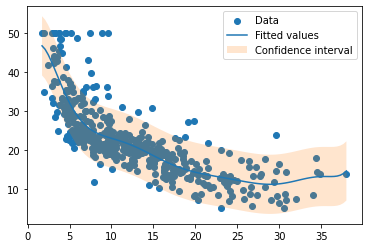

In [24]:
fit_poly.plot_fitted_values(alpha=0.05)

## Piecewise Step Functions

One of the most common piecewise functions is a Step function. Step function is a function which remains constant within the interval. We can fit individual step functions to each of the divided portions in order to avoid imposing a global structure. Here we break the range of X into bins, and fit a different constant in each bin.

In greater detail, we create cut points C1 , C2, . . . , Ck  in the range of X, and then construct K  + 1 new variables.

In [25]:
class PiecewiseStepRegression:
    def __init__(self, X_train, X_test, y_train, y_test, num_bins):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.num_bins = num_bins

    def fit_regression(self):
        df_cut, self.bins = pd.cut(self.X_train, self.num_bins, retbins=True, right=True)
        df_steps = pd.concat([self.X_train, df_cut, self.y_train], keys=['LSTAT','LSTAT_CUTS', "MEDV"], axis=1)
        df_steps_dummies = pd.get_dummies(df_cut)
        df_steps_dummies.columns = [f'{self.bins[i]}-{self.bins[i+1]}' for i in range(len(self.bins)-1)]
        self.fit = sm.GLM(df_steps["MEDV"], df_steps_dummies).fit()

    def predict(self):
        bin_mapping = np.digitize(self.X_test, self.bins)
        X_valid = pd.get_dummies(bin_mapping)
        self.pred = self.fit.predict(X_valid)
        self.rmse = np.sqrt(mean_squared_error(self.y_test, self.pred))
        return self.rmse

    def plot(self, num_samples=70):
        xp = np.linspace(self.X_test.min(), self.X_test.max()-1, num_samples) 
        bin_mapping = np.digitize(xp, self.bins) 
        X_valid_2= pd.get_dummies(bin_mapping) 
        pred = self.fit.predict(X_valid_2)

        fig, (ax1) = plt.subplots(1,1, figsize=(12,5))
        fig.suptitle('Piecewise Constant', fontsize=14)
        ax1.scatter(self.X_train, self.y_train, facecolor='None', edgecolor='k', alpha=0.3)
        ax1.plot(xp, pred, c='b')
        ax1.set_xlabel('LSTAT')
        ax1.set_ylabel('MEDV')
        plt.draw()


In [26]:
X_data=X['LSTAT']

In [27]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_data, y, test_size=0.33, random_state = 42)

In [28]:
# df_cut, bins = pd.cut(X_train, 4, retbins=True, right=True)
# df_steps = pd.concat([X_train, df_cut, y_train], keys=['lstat','lstat_cuts','medv'], axis=1)

# # Create dummy variables for the age groups
# df_steps_dummies = pd.get_dummies(df_cut)

RMSE: 6.224810132383494


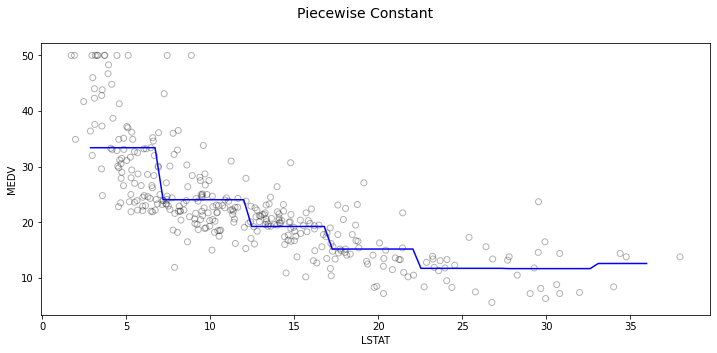

In [29]:
regression = PiecewiseStepRegression(X_train_p, X_test_p, y_train_p, y_test_p, 7)
fit = regression.fit_regression()
_ = regression.predict()
print("RMSE:", regression.rmse)
regression.plot()

## Regression Splines 

- Splines use low-degree polynomials over different regions of the predictor variable.
- The points where different polynomial changes are called `knots`.
- The optimal number and location of knots is a tuning parameter for regression splines.


In [30]:
class RegressionSplines:
    def __init__(self, X_train, X_test, y_train, y_test, knots, degree):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.knots = knots
        self.degree = degree
    
    def fit_model(self):
        transformed_x = dmatrix(f"bs(self.X_train, knots=self.knots, degree=self.degree, include_intercept=False)", return_type='dataframe')
        self.fit = sm.GLM(self.y_train, transformed_x).fit()
    
    def fit_model_ns(self):
        transformed_x = dmatrix(f"cr(self.X_train, df={len(self.knots) + self.degree - 2})", return_type='dataframe')
        self.fit_ns = sm.GLM(self.y_train, transformed_x).fit()
        
    def predict(self):
        pred = self.fit.predict(dmatrix(f"bs(self.X_test, knots=self.knots, include_intercept=False)", return_type='dataframe'))
        self.rmse = np.sqrt(mean_squared_error(self.y_test, pred))
        return self.rmse
    
    def predict_ns(self):
        pred = self.fit_ns.predict(dmatrix(f"cr(self.X_test, df={len(self.knots) + self.degree - 2})", return_type='dataframe'))
        self.rmse_ns = np.sqrt(mean_squared_error(self.y_test, pred))
        return self.rmse_ns
    
    def find_optimal_knots(self, max_knots, degree=3):
        min_rmse = float('inf')
        optimal_knots = []
        for i in range(1, max_knots+1):
            knots = np.linspace(self.X_train.min(), self.X_train.max(), i)
            self.knots = knots
            self.degree = degree
            self.fit_model()
            rmse = self.predict()
            if rmse < min_rmse:
                min_rmse = rmse
                optimal_knots = knots
        self.knots = optimal_knots
        self.degree = degree
        self.fit_model()
        return min_rmse, optimal_knots
    
    def confidence_interval(self, X, y_test, pred, alpha=0.05):
        n = len(X)
        t_value = norm.ppf(1-alpha/2)
        mse = mean_squared_error(y_test, pred)
        se = np.sqrt(mse * (1/n + (X - X.mean())**2 / ((X**2).sum() - n*(X.mean())**2)))
        conf_int = t_value * se
        return conf_int

    def plot(self):
        self.X_test = self.X_test.sort_values()
        pred = self.fit.predict(dmatrix(f"bs(self.X_test, knots=self.knots, include_intercept=False)", return_type='dataframe'))
        conf_int = self.confidence_interval(self.X_test, self.y_test, pred, alpha=0.05)
        plt.fill_between(self.X_test, pred - conf_int, pred + conf_int, color='blue', alpha=0.3)
        plt.scatter(self.X_test, self.y_test, facecolor='None', edgecolor='k', alpha=0.5)
        plt.plot(self.X_test, pred, label=f'Degree = {self.degree} with {len(self.knots)} knots')
        [plt.vlines(i , 0, 350, linestyles='dashed', lw=2, colors='b') for i in self.knots]
        plt.legend()
        plt.xlim(self.X_test.min(),self.X_test.max())
        plt.ylim(0,self.y_test.max())
        plt.xlabel(str(self.X_train.name))
        plt.ylabel(str(self.y_test.name))
        plt.show()
    

    def plot_ns(self):
        self.X_test = self.X_test.sort_values()
        pred = self.fit_ns.predict(dmatrix(f"cr(self.X_test, df={len(self.knots) + self.degree - 2})", return_type='dataframe'))
        conf_int = self.confidence_interval(self.X_test, self.y_test, pred, alpha=0.05)
        plt.fill_between(self.X_test, pred - conf_int, pred + conf_int, color='blue', alpha=0.3)
        plt.scatter(self.X_test, self.y_test, facecolor='Red', edgecolor='k', alpha=0.5)
        plt.plot(self.X_test, pred, label=f'Degree = {self.degree} with {len(self.knots)} knots')
        [plt.vlines(i , 0, 350, linestyles='dashed', lw=2, colors='b') for i in self.knots]
        plt.legend()
        plt.xlim(self.X_test.min(),self.X_test.max())
        plt.ylim(0,self.y_test.max())
        plt.xlabel(str(self.X_train.name))
        plt.ylabel(str(self.y_test.name))
        plt.show()

5.937772057977266


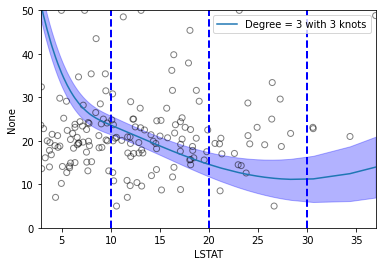

In [31]:
# Call method to fit cubic spline
spline_fitter = RegressionSplines(X_train_p, X_test_p, y_train_p, y_test_p, knots=(10, 20, 30), degree=3)
spline_fitter.fit_model()
rmse = spline_fitter.predict()
print(rmse)
spline_fitter.plot()

5.914650341798824


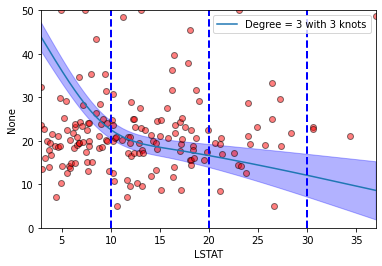

In [32]:
spline_fitter = RegressionSplines(X_train_p, X_test_p, y_train_p, y_test_p, knots=(10, 20, 30), degree=3)
spline_fitter.fit_model_ns()
rmse_ns = spline_fitter.predict_ns()
print(rmse_ns)
spline_fitter.plot_ns()

In [33]:
df = pd.read_csv('https://raw.githubusercontent.com/sukhjitsehra/datasets/master/CP322/Wage.csv')
X_w=df.age
y_w=df.wage
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y_w, test_size=0.3, random_state=42)

38.496003943893044


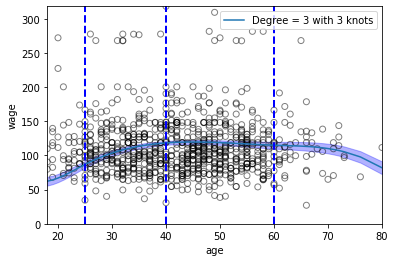

In [34]:
spline_fitter = RegressionSplines(X_train_w, X_test_w, y_train_w, y_test_w, knots=(25,40,60), degree=3)
spline_fitter.fit_model()
rmse = spline_fitter.predict()
print(rmse)
spline_fitter.plot()

38.45767321072304


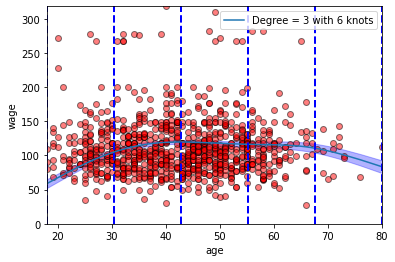

In [35]:
spline_fitter = RegressionSplines(X_train_w, X_test_w, y_train_w, y_test_w, knots=(18.,30.4, 42.8, 55.2, 67.6, 80.), degree=3)
spline_fitter.fit_model_ns()
rmse_ns = spline_fitter.predict_ns()
print(rmse_ns)
spline_fitter.plot_ns()

In [36]:
rmse, knots = spline_fitter.find_optimal_knots(10, degree=3)
print(knots)

[18.  33.5 49.  64.5 80. ]


## Smoothing Splines

In [37]:
class SmoothingSplines:
    def __init__(self, X_train, X_test, y_train, y_test, lam):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.lam = lam
        
    def fit_model(self):
        self.fit = sm.GLM(self.y_train, self.X_train, family=sm.families.Gamma(sm.families.links.Log())).fit_regularized(method='elastic_net', alpha=self.lam)
    
    def predict(self):
        pred = self.fit.predict(self.X_test)
        self.rmse = np.sqrt(mean_squared_error(self.y_test, pred))
        return self.rmse
    
    def confidence_interval(self, X, y_test, pred, alpha=0.05):
        n = len(X)
        t_value = norm.ppf(1-alpha/2)
        mse = mean_squared_error(y_test, pred)
        se = np.sqrt(mse * (1/n + (X - X.mean())**2 / ((X**2).sum() - n*(X.mean())**2)))
        conf_int = t_value * se
        return conf_int
    
    def plot(self):
        self.X_test = self.X_test.sort_values()
        pred = self.fit.predict(self.X_test)
        conf_int = self.confidence_interval(self.X_test, self.y_test, pred, alpha=0.05)
        plt.fill_between(self.X_test, pred - conf_int, pred + conf_int, color='blue', alpha=0.3)
        plt.scatter(self.X_test, self.y_test, facecolor='None', edgecolor='k', alpha=0.5)
        plt.plot(self.X_test, pred, label=f'Lambda = {self.lam}')
        plt.legend()
        plt.xlim(self.X_test.min(),self.X_test.max())
        plt.ylim(0,self.y_test.max())
        plt.xlabel(str(self.X_train.name))
        plt.ylabel(str(self.y_test.name))
        plt.show()
        
    def find_optimal_lambda(self, lam_range_max):
        lam_range = np.arange(0, lam_range_max, .1)
        best_rmse = float("inf")
        best_lam = 0
        for lam in lam_range:
            self.lam = lam
            self.fit_model()
            rmse = self.predict()
            if rmse < best_rmse:
                best_rmse = rmse
                best_lam = lam
        self.lam = best_lam
        self.fit_model()
        return best_lam


895.4406341344377


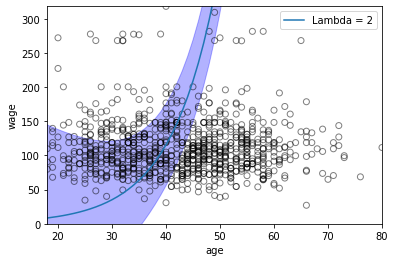

In [38]:
smooth_spline = SmoothingSplines(X_train_w, X_test_w, y_train_w, y_test_w, lam= 2)
smooth_spline.fit_model()
rmse = smooth_spline.predict()
print(rmse)
smooth_spline.plot()

In [39]:
lamb = smooth_spline.find_optimal_lambda(10)
lamb

9.9

In [40]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import patsy

class GeneralizedAdditiveModel:
    def __init__(self, X_train, X_test, y_train, y_test):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.basis_func_train = f"cr(self.X_train, df=4)"
        self.basis_func_test = f"cr(self.X_test, df=4)"
        
    def fit_model(self):
        # transformed_x = dmatrix(f"cr(self.X_train, df={len(self.knots) + self.degree - 2})", return_type='dataframe')
        # self.fit_ns = sm.GLM(self.y_train, transformed_x).fit()
        transformed_x = dmatrix(self.basis_func_train, return_type='dataframe')
        self.fit = sm.GLM(self.y_train, transformed_x).fit()

    def predict(self):
        X_test_design = dmatrix(self.basis_func_test, return_type='dataframe')
        pred = self.fit.predict(X_test_design)
        self.rmse = np.sqrt(mean_squared_error(self.y_test, pred))
        return self.rmse
       
    def plot(self):
        xp = np.linspace(self.X_test.min(), self.X_test.max(),70)
        X_test_design = dmatrix(f"cr(xp, df=4)", return_type='dataframe')
        pred = self.fit.predict(X_test_design)
        plt.scatter(self.X_test, self.y_test, facecolor='None', edgecolor='k', alpha=0.5)
        plt.plot(xp, pred)
        plt.legend()
        plt.xlim(self.X_test.min(),self.X_test.max())
        plt.ylim(0,self.y_test.max())
        plt.xlabel(str(self.X_train.name))
        plt.ylabel(str(self.y_test.name))
        plt.show()


In [41]:
gam_fitter= GeneralizedAdditiveModel(X_train_w, X_test_w, y_train_w, y_test_w)
gam_fitter.fit_model()
rmse_ns = gam_fitter.predict()
print(rmse_ns)

38.59144179262173


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


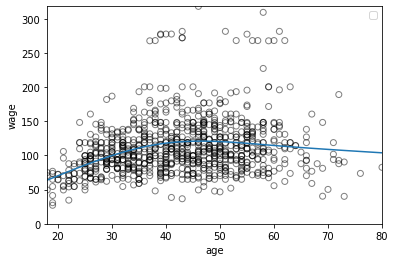

In [42]:
gam_fitter.plot()